In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, confusion_matrix
)
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import shap
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout

C:\Users\mjaye\miniconda3\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\mjaye\miniconda3\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\mjaye\miniconda3\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/resource_handle.proto. Please update the gencode to avoid compatibility violations i

In [11]:
data = pd.read_csv("final_dataset.csv")
data = data[~(data['pathology.lymph_nodes_positive_ratio'] == np.inf)]
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 320 entries, 0 to 320
Data columns (total 29 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   disease_type                          320 non-null    object 
 1   demographic.gender                    320 non-null    object 
 2   demographic.vital_status              320 non-null    object 
 3   demographic.age_at_index              320 non-null    float64
 4   primary_site                          320 non-null    object 
 5   diagnosis.synchronous_malignancy      320 non-null    object 
 6   diagnosis.pathologic_stage            320 non-null    object 
 7   diagnosis.organ_of_origin             320 non-null    object 
 8   diagnosis.primary_diagnosis           320 non-null    object 
 9   diagnosis.prior_malignancy            320 non-null    object 
 10  diagnosis.prior_treatment             320 non-null    object 
 11  diagnosis.is_primary_dis

In [12]:
target = "diagnosis.residual_disease"

X = data.drop(columns=[target])
y = data[target]
le = LabelEncoder()
y = le.fit_transform(y)   # R0=0, Rx=1

X_encoded = X.copy()
for col in X_encoded.select_dtypes(include=["object"]).columns:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
num_classes = len(np.unique(y))

In [13]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42),
    "LightGBM": LGBMClassifier(random_state=42)
}

results = []
roc_curves = {}

for name, model in models.items():
    # Logistic Regression needs scaled data
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:,1] if num_classes == 2 else None
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:,1] if num_classes == 2 else None

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted")
    rec = recall_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")
    auc = roc_auc_score(y_test, y_prob) if y_prob is not None else None

    results.append({"Model": name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1-score": f1, "AUC": auc})

    if y_prob is not None:
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_curves[name] = (fpr, tpr, auc)

[LightGBM] [Info] Number of positive: 34, number of negative: 222
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000398 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 332
[LightGBM] [Info] Number of data points in the train set: 256, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.132812 -> initscore=-1.876317
[LightGBM] [Info] Start training from score -1.876317
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


C:\Users\mjaye\miniconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [23:19:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [14]:
mlp = Sequential([
    Dense(128, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid") if num_classes == 2 else Dense(num_classes, activation="softmax")
])

mlp.compile(
    optimizer="adam",
    loss="binary_crossentropy" if num_classes == 2 else "categorical_crossentropy",
    metrics=["accuracy"]
)

# Convert labels for multi-class
y_train_mlp = y_train if num_classes == 2 else tf.keras.utils.to_categorical(y_train)
y_test_mlp = y_test if num_classes == 2 else tf.keras.utils.to_categorical(y_test)

mlp.fit(X_train_scaled, y_train_mlp, validation_split=0.2, epochs=30, batch_size=32, verbose=0)

mlp_pred = mlp.predict(X_test_scaled)

if num_classes == 2:
    mlp_pred_classes = (mlp_pred > 0.5).astype("int32")
    auc = roc_auc_score(y_test, mlp_pred)
else:
    mlp_pred_classes = np.argmax(mlp_pred, axis=1)
    auc = None

acc = accuracy_score(y_test, mlp_pred_classes)
prec = precision_score(y_test, mlp_pred_classes, average="weighted")
rec = recall_score(y_test, mlp_pred_classes, average="weighted")
f1 = f1_score(y_test, mlp_pred_classes, average="weighted")

results.append({"Model": "MLP", "Accuracy": acc, "Precision": prec, "Recall": rec, "F1-score": f1, "AUC": auc})
results_df = pd.DataFrame(results)
print("\n=== Model Comparison Results ===")
print(results_df)

C:\Users\mjaye\miniconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

=== Model Comparison Results ===
                 Model  Accuracy  Precision    Recall  F1-score       AUC
0  Logistic Regression  0.890625   0.872268  0.890625  0.868104  0.863839
1        Random Forest  0.968750   0.969828  0.968750  0.966792  1.000000
2    Gradient Boosting  0.984375   0.984649  0.984375  0.983923  0.993304
3              XGBoost  0.953125   0.955508  0.953125  0.948328  0.986607
4             LightGBM  0.968750   0.969828  0.968750  0.966792  0.979911
5                  MLP  0.921875   0.928279  0.921875  0.905789  0.837054


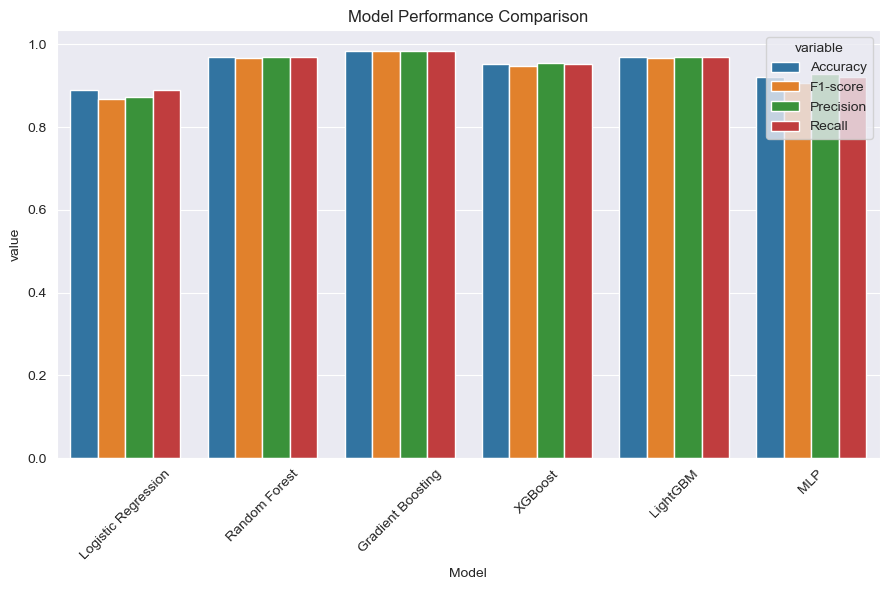

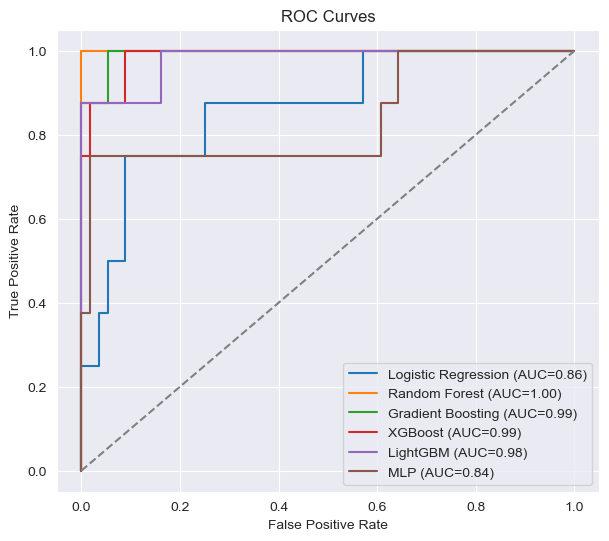

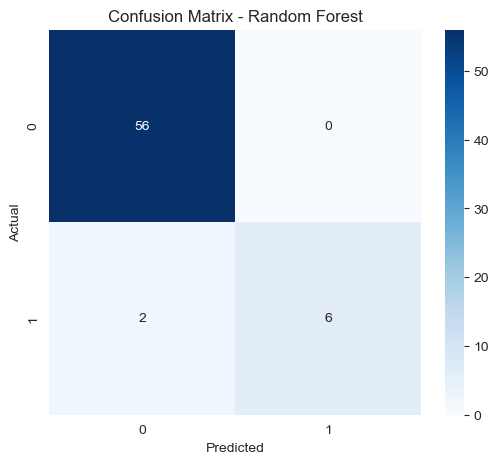

In [15]:
# --- Bar Plot ---
plt.figure(figsize=(9,6))
sns.barplot(data=results_df.melt(id_vars="Model", value_vars=["Accuracy","F1-score","Precision","Recall"]),
            x="Model", y="value", hue="variable")
plt.title("Model Performance Comparison")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- ROC Curves ---
if num_classes == 2:
    plt.figure(figsize=(7,6))
    for name, (fpr, tpr, auc) in roc_curves.items():
        plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.2f})")
    fpr, tpr, _ = roc_curve(y_test, mlp_pred)
    plt.plot(fpr, tpr, label=f"MLP (AUC={roc_auc_score(y_test, mlp_pred):.2f})")
    plt.plot([0,1],[0,1],"--", color="gray")
    plt.title("ROC Curves")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()

# --- Confusion Matrix (RF Example) ---
cm = confusion_matrix(y_test, models["Random Forest"].predict(X_test))
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

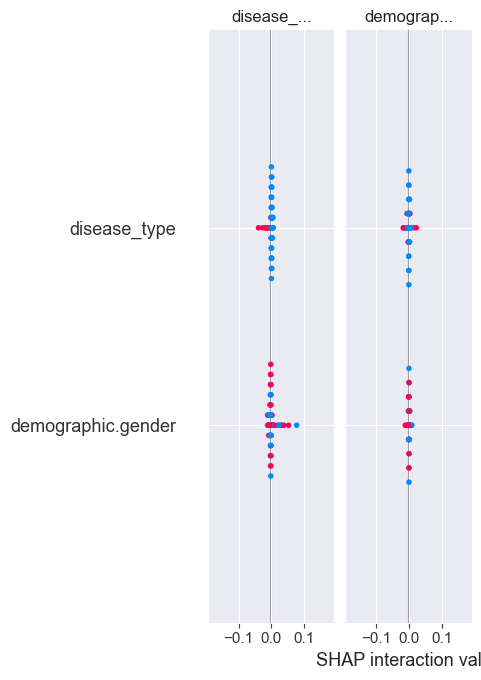

In [16]:
# --- SHAP Interpretability (RF Example) ---
explainer = shap.TreeExplainer(models["Random Forest"])
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, plot_type="bar")